#  Notebook Overview: Sequential Prompt Isolation Experiment

This notebook performs a rigorous comparative evaluation between different text prompts ("segment crack" vs "segment wall crack") by training two completely isolated model instances.

###  Execution Steps:
1. **Environment Setup:** Installs PyTorch, CLIP, and Segment-Anything (SAM) dependencies.
2. **Configuration:** Defines experimental parameters (image size 224, learning rate 3e-4) and isolated prompts.
3. **Dataset Loading:** Implements a custom `CrackDataset` to read images and masks from `cracks_dataset_v2`.
4. **Architecture Definition:** Constructs the `AdvancedSAMFiLM` model integrating:
   - **SAM (ViT-B)** Image Encoder.
   - **FiLM Generator** for text-based feature modulation.
   - **Dilated Decoder** for multi-scale context aggregation.
   - **Edge-Aware Head** using Laplacian edge features for refinement.
5. **Loss Function:** Implements a composite loss combining **Weighted BCE**, **Dice**, and **Edge-Aware** penalties to handle class imbalance.
6. **Isolated Training Phase:** 
   - Trains Model A exclusively on the prompt: `"segment crack"`.
   - Trains Model B exclusively on the prompt: `"segment wall crack"`.
7. **Side-by-Side Evaluation:** Calculates high-precision metrics (IoU, mIoU, Precision, Recall, F1) for both models on the test set.
8. **Visual Conflict Analysis:** Generates direct comparative visualizations showing how different prompt-trained models behave on the same input samples.


In [1]:
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import clip
from segment_anything import sam_model_registry

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

class Config:
    DATASET_DIR = "cracks_dataset_v2" 
    PROMPT_A = "segment crack"
    PROMPT_B = "segment wall crack"
    IMAGE_SIZE = 224
    BATCH_SIZE = 4
    NUM_EPOCHS = 10
    LEARNING_RATE = 3e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
print(f"Using Accelerated Device: {cfg.DEVICE}")


/home/nagendra/anaconda3/envs/crk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Accelerated Device: cuda


In [2]:
class CrackDataset(Dataset):
    def __init__(self, split, dataset_dir, image_size=224):
        self.split, self.image_size = split, image_size
        self.dataset_dir = dataset_dir
        with open(os.path.join(dataset_dir, "metadata.json"), "r") as f:
            metadata = json.load(f)
        
        self.samples = [m for m in metadata["images"] if m["split"] == split and os.path.exists(os.path.join(dataset_dir, split, "masks", m["mask_file"]))]
        print(f"{split.upper()}: Loaded {len(self.samples)} valid items.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(os.path.join(self.dataset_dir, self.split, "images", s["image_file"])).convert("RGB")
        mask = Image.open(os.path.join(self.dataset_dir, self.split, "masks", s["mask_file"])).convert("L")
        return transforms.ToTensor()(img.resize((self.image_size, self.image_size), Image.BILINEAR)), torch.from_numpy(np.array(mask.resize((self.image_size, self.image_size), Image.NEAREST))).float() / 255.0

train_ds = CrackDataset("train", cfg.DATASET_DIR, cfg.IMAGE_SIZE)
val_ds = CrackDataset("val", cfg.DATASET_DIR, cfg.IMAGE_SIZE)
test_ds = CrackDataset("test", cfg.DATASET_DIR, cfg.IMAGE_SIZE)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)


TRAIN: Loaded 3756 valid items.
VAL: Loaded 805 valid items.
TEST: Loaded 806 valid items.


In [3]:
class FiLMGenerator(nn.Module):
    def __init__(self, text_dim=512, feat_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(text_dim, 256), nn.ReLU(inplace=True), nn.Linear(256, 256), nn.ReLU(inplace=True), nn.Linear(256, feat_dim * 2))
        nn.init.zeros_(self.mlp[-1].weight); nn.init.zeros_(self.mlp[-1].bias)
        with torch.no_grad(): self.mlp[-1].bias[:feat_dim] = 1.0
    def forward(self, text_emb):
        out = self.mlp(text_emb)
        return out[:, :256], out[:, 256:]
    def modulate(self, features, gamma, beta):
        return gamma[:, :, None, None] * features + beta[:, :, None, None]

class DilatedDecoder(nn.Module):
    def __init__(self, in_dim=256, out_dim=128):
        super().__init__()
        b_dim = in_dim // 4
        self.global_ctx = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dim, b_dim, 1), nn.ReLU(inplace=True))
        self.d1 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=1, dilation=1, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d3 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=3, dilation=3, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d6 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=6, dilation=6, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d12 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=12, dilation=12, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.project = nn.Sequential(nn.Conv2d(b_dim * 5, out_dim, 1), nn.GroupNorm(8, out_dim), nn.ReLU(inplace=True), nn.Dropout2d(0.1))
    def forward(self, x):
        ctx = self.global_ctx(x).expand(-1, -1, x.shape[2], x.shape[3])
        return self.project(torch.cat([ctx, self.d1(x), self.d3(x), self.d6(x), self.d12(x)], dim=1))

class EdgeAwareHead(nn.Module):
    def __init__(self, feat_dim=16):
        super().__init__()
        lap = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).repeat(1, 1, 1, 1)
        self.register_buffer("lap_kernel", lap)
        self.edge_enc = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(inplace=True))
        self.channel_attn = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(feat_dim + 16, 16), nn.ReLU(inplace=True), nn.Linear(16, feat_dim), nn.Sigmoid())
        self.refine = nn.Sequential(nn.Conv2d(feat_dim + 16, feat_dim, 3, padding=1), nn.GroupNorm(4, feat_dim), nn.ReLU(inplace=True), nn.Conv2d(feat_dim, feat_dim // 2, 3, padding=1), nn.GroupNorm(4, feat_dim // 2), nn.ReLU(inplace=True))
        self.head = nn.Conv2d(feat_dim // 2, 1, 1)
    def extract_edges(self, image):
        e = F.conv2d(0.299*image[:, 0:1] + 0.587*image[:, 1:2] + 0.114*image[:, 2:3], self.lap_kernel, padding=1).abs()
        return e / e.view(e.shape[0], -1).max(dim=1)[0].view(e.shape[0], 1, 1, 1).clamp(min=1e-6)
    def forward(self, feats, image):
        edge_feats = self.edge_enc(self.extract_edges(F.interpolate(image, size=(feats.shape[2], feats.shape[3]), mode="bilinear", align_corners=False)))
        attn = self.channel_attn(torch.cat([feats, edge_feats], dim=1))[:, :, None, None]
        return self.head(self.refine(torch.cat([feats * attn, edge_feats], dim=1)))

class AdvancedSAMFiLM(nn.Module):
    def __init__(self, image_size=224):
        super().__init__()
        self.sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
        new_pos = F.interpolate(self.sam.image_encoder.pos_embed.permute(0, 3, 1, 2), size=(image_size//16, image_size//16), mode='bicubic', align_corners=False)
        self.sam.image_encoder.pos_embed = nn.Parameter(new_pos.permute(0, 2, 3, 1)) 
        for param in self.sam.image_encoder.parameters(): param.requires_grad = False
        
        self.film = FiLMGenerator(512, 256)
        self.dilated = DilatedDecoder(256, 128)
        self.upsampler = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.edge_head = EdgeAwareHead(16)
        
    def forward(self, img, text_emb):
        with torch.no_grad(): img_features = self.sam.image_encoder(img)
        gamma, beta = self.film(text_emb)
        return self.edge_head(self.upsampler(self.dilated(self.film.modulate(img_features, gamma, beta))), img).squeeze(1)

print("Booting Vision Models...")
clip_model, _ = clip.load("ViT-B/32", cfg.DEVICE)
clip_model = clip_model.float().eval()


Booting Vision Models...


In [4]:
# 3. Class Imbalance Segmentation Loss
class SegmentationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("lap_kernel", torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0))

    def forward(self, logits, targets):
        if logits.dim() == 3: logits = logits.unsqueeze(1)
        if targets.dim() == 3: targets = targets.unsqueeze(1)
        
        l_bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=torch.tensor([15.0], device=logits.device))
        
        probs = torch.sigmoid(logits)
        inter = (probs * targets).flatten(1).sum(dim=1)
        union = probs.flatten(1).sum(dim=1) + targets.flatten(1).sum(dim=1)
        l_dice = (1.0 - (2.0 * inter + 1e-5) / (union + 1e-5)).mean()
        
        gt_edges = (F.conv2d(targets, self.lap_kernel, padding=1).abs() > 0.1).float()
        l_edge = (F.binary_cross_entropy_with_logits(logits, targets, reduction="none") * (1.0 + 5.0 * gt_edges)).mean()
        
        return l_bce + 2.0 * l_dice + 0.2 * l_edge


In [6]:
# 4. Independent Model Training Procedure (WITH FULL METRICS)
def train_isolated_model(target_prompt, save_filename):
    print("\n" + "="*80)
    print(f"🚀 INITIATING COMPLETELY ISOLATED TRAINING FOR: '{target_prompt}'")
    print("="*80)
    
    model = AdvancedSAMFiLM().to(cfg.DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LEARNING_RATE)
    criterion = SegmentationLoss().to(cfg.DEVICE)
    
    with torch.no_grad():
        target_emb_single = clip_model.encode_text(clip.tokenize(target_prompt).to(cfg.DEVICE)).detach()[0]
    
    best_miou = 0
    
    for epoch in range(cfg.NUM_EPOCHS):
        model.train()
        train_loss = 0.0
        t_inter, t_psum, t_tsum, t_inter_bg, t_psum_bg, t_tsum_bg = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
            images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
            text_emb = torch.stack([target_emb_single for _ in range(images.shape[0])])
            
            optimizer.zero_grad()
            logits = model(images, text_emb)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
            with torch.no_grad():
                p, t = (torch.sigmoid(logits) > 0.5).float().flatten(1), masks.float().flatten(1)
                p_bg, t_bg = 1.0 - p, 1.0 - t
                t_inter += (p * t).sum().item(); t_psum += p.sum().item(); t_tsum += t.sum().item()
                t_inter_bg += (p_bg * t_bg).sum().item(); t_psum_bg += p_bg.sum().item(); t_tsum_bg += t_bg.sum().item()
                
        t_loss = train_loss / len(train_loader)
        t_iou_fg = (t_inter + 1e-8) / (t_psum + t_tsum - t_inter + 1e-8)
        t_miou = (t_iou_fg + (t_inter_bg+1e-8)/(t_psum_bg+t_tsum_bg-t_inter_bg+1e-8)) / 2.0
        t_prec = (t_inter + 1e-8) / (t_psum + 1e-8)
        t_rec  = (t_inter + 1e-8) / (t_tsum + 1e-8)
        t_f1   = 2 * t_prec * t_rec / (t_prec + t_rec + 1e-8)
        t_dice = (2 * t_inter + 1e-8) / (t_psum + t_tsum + 1e-8)
        
        model.eval()
        val_loss = 0.0
        v_inter, v_psum, v_tsum, v_inter_bg, v_psum_bg, v_tsum_bg = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} Val  "):
                images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
                text_emb = torch.stack([target_emb_single for _ in range(images.shape[0])])
                logits = model(images, text_emb)
                val_loss += criterion(logits, masks).item()
                
                p, t = (torch.sigmoid(logits) > 0.5).float().flatten(1), masks.float().flatten(1)
                p_bg, t_bg = 1.0 - p, 1.0 - t
                v_inter += (p * t).sum().item(); v_psum += p.sum().item(); v_tsum += t.sum().item()
                v_inter_bg += (p_bg * t_bg).sum().item(); v_psum_bg += p_bg.sum().item(); v_tsum_bg += t_bg.sum().item()
                
        v_loss = val_loss / len(val_loader)
        v_iou_fg = (v_inter + 1e-8) / (v_psum + v_tsum - v_inter + 1e-8)
        v_miou = (v_iou_fg + (v_inter_bg+1e-8)/(v_psum_bg+v_tsum_bg-v_inter_bg+1e-8)) / 2.0
        v_prec = (v_inter + 1e-8) / (v_psum + 1e-8)
        v_rec  = (v_inter + 1e-8) / (v_tsum + 1e-8)
        v_f1   = 2 * v_prec * v_rec / (v_prec + v_rec + 1e-8)
        v_dice = (2 * v_inter + 1e-8) / (v_psum + v_tsum + 1e-8)
        
        print(f"\n--- [ '{target_prompt}' ] Epoch {epoch+1:02d}/{cfg.NUM_EPOCHS} ---")
        print(f"TRAIN | Loss: {t_loss:.4f} | IoU: {t_iou_fg:.4f} | mIoU: {t_miou:.4f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f} | F1: {t_f1:.4f} | Dice: {t_dice:.4f}")
        print(f"VAL   | Loss: {v_loss:.4f} | IoU: {v_iou_fg:.4f} | mIoU: {v_miou:.4f} | Prec: {v_prec:.4f} | Rec: {v_rec:.4f} | F1: {v_f1:.4f} | Dice: {v_dice:.4f}")
        print("-" * 100)
        
        if v_iou_fg > best_miou:
            best_miou = v_iou_fg
            torch.save(model.state_dict(), save_filename)
            
    print(f" Best Validation IoU (Foreground Crack): {best_miou:.4f}")

# Train the two isolated mathematical bodies sequentially
file_A = train_isolated_model(cfg.PROMPT_A, "model_prompt_A.pth")
file_B = train_isolated_model(cfg.PROMPT_B, "model_prompt_B.pth")



🚀 INITIATING COMPLETELY ISOLATED TRAINING FOR: 'segment crack'


Epoch 1 Val  : 100%|██████████████████████████| 202/202 [00:10<00:00, 18.66it/s]



--- [ 'segment crack' ] Epoch 01/10 ---
TRAIN | Loss: 2.2816 | IoU: 0.2502 | mIoU: 0.5645 | Prec: 0.2614 | Rec: 0.8531 | F1: 0.4002 | Dice: 0.4002
VAL   | Loss: 1.9553 | IoU: 0.2914 | mIoU: 0.5947 | Prec: 0.3034 | Rec: 0.8806 | F1: 0.4513 | Dice: 0.4513
----------------------------------------------------------------------------------------------------


Epoch 2 Val  : 100%|██████████████████████████| 202/202 [00:09<00:00, 22.36it/s]



--- [ 'segment crack' ] Epoch 02/10 ---
TRAIN | Loss: 1.8164 | IoU: 0.3471 | mIoU: 0.6366 | Prec: 0.3734 | Rec: 0.8316 | F1: 0.5154 | Dice: 0.5154
VAL   | Loss: 1.7580 | IoU: 0.4092 | mIoU: 0.6790 | Prec: 0.4746 | Rec: 0.7478 | F1: 0.5807 | Dice: 0.5807
----------------------------------------------------------------------------------------------------


...


--- [ 'segment wall crack' ] Epoch 08/10 ---
TRAIN | Loss: 1.2772 | IoU: 0.4959 | mIoU: 0.7270 | Prec: 0.5353 | Rec: 0.8707 | F1: 0.6630 | Dice: 0.6630
VAL   | Loss: 1.5721 | IoU: 0.4038 | mIoU: 0.6719 | Prec: 0.4337 | Rec: 0.8540 | F1: 0.5753 | Dice: 0.5753
----------------------------------------------------------------------------------------------------


Epoch 9 Val  : 100%|██████████████████████████| 202/202 [00:10<00:00, 19.41it/s]



--- [ 'segment wall crack' ] Epoch 09/10 ---
TRAIN | Loss: 1.2327 | IoU: 0.5095 | mIoU: 0.7347 | Prec: 0.5483 | Rec: 0.8781 | F1: 0.6751 | Dice: 0.6751
VAL   | Loss: 1.5475 | IoU: 0.4329 | mIoU: 0.6915 | Prec: 0.4841 | Rec: 0.8034 | F1: 0.6042 | Dice: 0.6042
----------------------------------------------------------------------------------------------------


Epoch 10 Val  : 100%|█████████████████████████| 202/202 [00:07<00:00, 27.87it/s]



--- [ 'segment wall crack' ] Epoch 10/10 ---
TRAIN | Loss: 1.1892 | IoU: 0.5241 | mIoU: 0.7430 | Prec: 0.5632 | Rec: 0.8830 | F1: 0.6877 | Dice: 0.6877
VAL   | Loss: 1.5290 | IoU: 0.4538 | mIoU: 0.7038 | Prec: 0.5081 | Rec: 0.8093 | F1: 0.6243 | Dice: 0.6243
----------------------------------------------------------------------------------------------------
 Best Validation IoU (Foreground Crack): 0.4680


In [9]:
# 5. EXPERIMENTAL COMPARISON EVALUATION (FULL SCORECARDS)
print("\n" + "="*80)
print(f" RUNNING SIDE-BY-SIDE ISOLATED EXPERIMENTS")
print("="*80)

def evaluate_isolated(target_prompt, weights_file):
    model = AdvancedSAMFiLM().to(cfg.DEVICE)
    model.load_state_dict(torch.load(weights_file))
    model.eval()
    
    with torch.no_grad():
        target_emb_single = clip_model.encode_text(clip.tokenize(target_prompt).to(cfg.DEVICE)).detach()[0]
    
    t_loss = 0.0
    inter, psum, tsum, inter_bg, psum_bg, tsum_bg = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    criterion = SegmentationLoss().to(cfg.DEVICE)
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f"Testing {target_prompt}"):
            images = images.to(cfg.DEVICE, non_blocking=True)
            masks = masks.to(cfg.DEVICE, non_blocking=True)
            
            text_emb = torch.stack([target_emb_single for _ in range(images.shape[0])])
            logits = model(images, text_emb)
            t_loss += criterion(logits, masks).item()
            
            p = (torch.sigmoid(logits) > 0.5).float().flatten(1)
            t = masks.float().flatten(1)
            p_bg, t_bg = 1.0 - p, 1.0 - t
            
            inter += (p * t).sum().item(); psum += p.sum().item(); tsum += t.sum().item()
            inter_bg += (p_bg * t_bg).sum().item(); psum_bg += p_bg.sum().item(); tsum_bg += t_bg.sum().item()
            
    test_loss = t_loss / len(test_loader)
    iou_fg = (inter + 1e-8) / (psum + tsum - inter + 1e-8)
    iou_bg = (inter_bg + 1e-8) / (psum_bg + tsum_bg - inter_bg + 1e-8)
    miou = (iou_fg + iou_bg) / 2.0
    
    prec = (inter + 1e-8) / (psum + 1e-8)
    rec  = (inter + 1e-8) / (tsum + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    dice = (2 * inter + 1e-8) / (psum + tsum + 1e-8)
    
    print(f"\n SCORECARD: [ {target_prompt} ]")
    print(f"Test Loss: {test_loss:.4f} | IoU: {iou_fg:.4f} | mIoU: {miou:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1 Score: {f1:.4f} | Dice: {dice:.4f}")
    
    return model, target_emb_single

model_A, emb_A = evaluate_isolated(cfg.PROMPT_A, "model_prompt_A.pth")
model_B, emb_B = evaluate_isolated(cfg.PROMPT_B, "model_prompt_B.pth")



 RUNNING SIDE-BY-SIDE ISOLATED EXPERIMENTS


/tmp/ipykernel_653881/2811608680.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_file))
Testing segment crack: 100%|████████████


 SCORECARD: [ segment crack ]
Test Loss: 1.5869 | IoU: 0.4457 | mIoU: 0.6988 | Precision: 0.5096 | Recall: 0.7805 | F1 Score: 0.6166 | Dice: 0.6166


Testing segment wall crack: 100%|█████████████| 202/202 [00:19<00:00, 10.22it/s]



 SCORECARD: [ segment wall crack ]
Test Loss: 1.6879 | IoU: 0.4587 | mIoU: 0.7084 | Precision: 0.5584 | Recall: 0.7199 | F1 Score: 0.6290 | Dice: 0.6290



Plotting 8 Direct Visual Comparisons side-by-side...


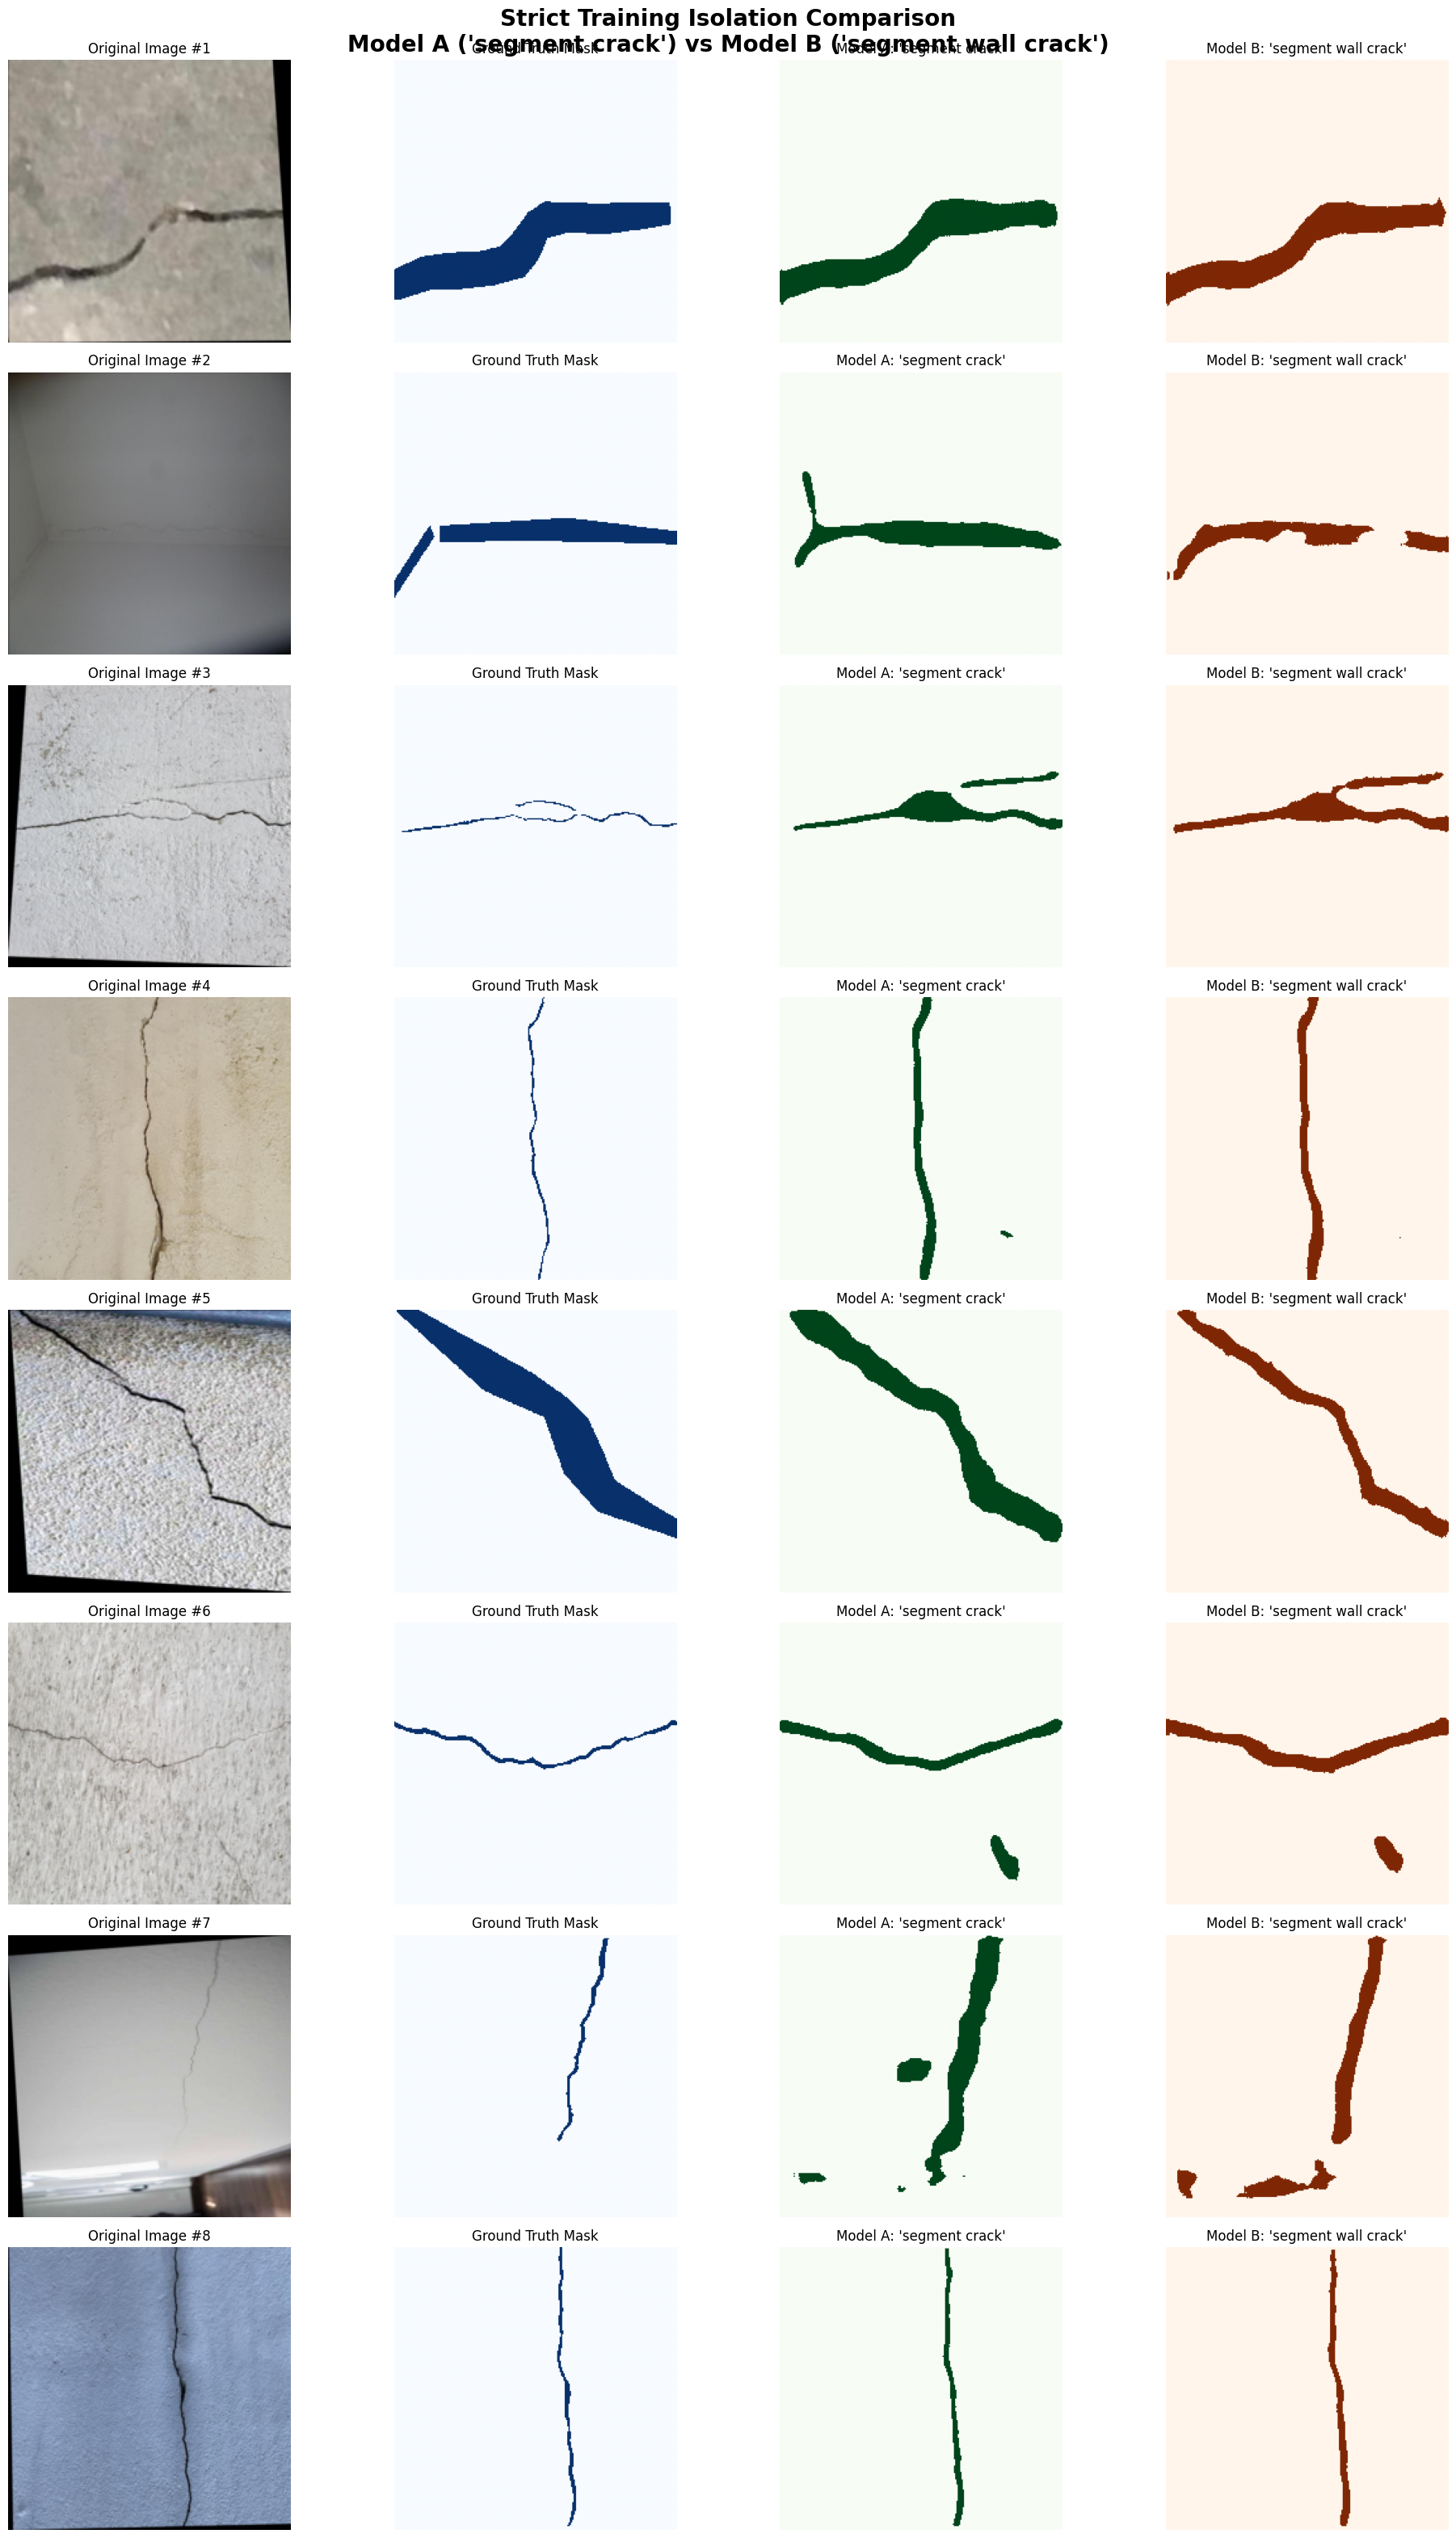

In [10]:
# 6. VISUAL DIRECT CONFLICT COMPARISON
print("\nPlotting 8 Direct Visual Comparisons side-by-side...")
fig, axes = plt.subplots(8, 4, figsize=(20, 32))
fig.suptitle(f"Strict Training Isolation Comparison\nModel A ('{cfg.PROMPT_A}') vs Model B ('{cfg.PROMPT_B}')", fontsize=20, fontweight='bold')

examples_shown = 0
with torch.no_grad():
    for images, masks in test_loader:
        images_cuda = images.to(cfg.DEVICE)
        
        for i in range(len(images)):
            if examples_shown >= 8: break
            
            img_slice = images_cuda[i].unsqueeze(0)
            
            # Use Model A exclusively with Prompt A
            pred_A_mask = (torch.sigmoid(model_A(img_slice, emb_A.unsqueeze(0))).cpu().squeeze().numpy() > 0.5).astype(np.float32)
            # Use Model B exclusively with Prompt B
            pred_B_mask = (torch.sigmoid(model_B(img_slice, emb_B.unsqueeze(0))).cpu().squeeze().numpy() > 0.5).astype(np.float32)
            
            orig = images[i].permute(1, 2, 0).numpy()
            gt = masks[i].squeeze().numpy()
            
            axes[examples_shown, 0].imshow(orig)
            axes[examples_shown, 0].set_title(f"Original Image #{examples_shown+1}")
            axes[examples_shown, 0].axis("off")
            
            axes[examples_shown, 1].imshow(gt, cmap="Blues")
            axes[examples_shown, 1].set_title("Ground Truth Mask")
            axes[examples_shown, 1].axis("off")
            
            axes[examples_shown, 2].imshow(pred_A_mask, cmap="Greens")
            axes[examples_shown, 2].set_title(f"Model A: '{cfg.PROMPT_A}'")
            axes[examples_shown, 2].axis("off")
            
            axes[examples_shown, 3].imshow(pred_B_mask, cmap="Oranges")
            axes[examples_shown, 3].set_title(f"Model B: '{cfg.PROMPT_B}'")
            axes[examples_shown, 3].axis("off")
            
            examples_shown += 1
            
        if examples_shown >= 8: break

plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()
